# Построение simple CNN на PyTorch под датасет Car damage

## Библиотеки

In [1]:
import os
from pathlib import Path
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
import torch.nn.functional as F
from IPython.display import display

plt.style.use('dark_background')
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

device: mps


## Фиксация генератора случайных чисел для воспроизводимости результатов

In [2]:
def seed_everything(seed: int = 42):
    start_time = time.time()

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.mps.is_available():
        torch.mps.manual_seed(seed)

    print(f"Seed set time: {time.time() - start_time}")

## Основные параметры

In [3]:
TRAIN_DIR = 'data1a/training'
TEST_DIR = 'data1a/validation'

TARGET_SIZE = (128, 128)
BATCH_SIZE = 256
EPOCHS = 150
PATIENCE = EPOCHS*0.7
MIN_DELTA = 0.001
LEARNING_RATE = 1e-3
EPSILON = 1e-6
SAVE_CHECKPOINT = False

SEED = 123
seed_everything(SEED)

Seed set time: 0.004786968231201172


## Датасет и трансформации

In [4]:
transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE, interpolation=InterpolationMode.NEAREST),
    #transforms.Grayscale(num_output_channels=1),
    transforms.PILToTensor()
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)

assert train_dataset.class_to_idx == test_dataset.class_to_idx, \
    "Классы training и validation должны совпадать"


def cache_dataset(dataset):
    """Заранее кешируем картинки и кладем на устройство"""
    images = torch.stack([image for image, _ in dataset]).to(device)
    labels = torch.tensor(dataset.targets, device=device)
    return images, labels


class CachedLoader:
    """Замена DataLoader для датасета, целиком лежащего на устройстве"""
    # Батчи режутся срезами тензора: без диска, без декодирования JPEG, без копирования CPU - GPU (unified memory, но без лишних переходов)
    def __init__(self, images, labels, batch_size, shuffle):
        self.images, self.labels = images, labels
        self.batch_size, self.shuffle = batch_size, shuffle

    def __len__(self):
        return (len(self.images) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        n = len(self.images)
        order = torch.randperm(n, device=self.images.device) if self.shuffle else None
        for start in range(0, n, self.batch_size):
            idx = order[start:start + self.batch_size] if self.shuffle else slice(start, start + self.batch_size)
            yield self.images[idx], self.labels[idx]


start_time = time.time()
train_images, train_labels = cache_dataset(train_dataset)
test_images, test_labels = cache_dataset(test_dataset)
print(f'Ушло на кеш {time.time() - start_time:.1f} сек., '
      f'{(train_images.nbytes + test_images.nbytes) / 1e6:.0f} мб, DEVICE: {device}')

training_set = CachedLoader(train_images, train_labels, BATCH_SIZE, shuffle=True)
testing_set = CachedLoader(test_images, test_labels, BATCH_SIZE, shuffle=False)

print('Классы:', train_dataset.class_to_idx)
print('Training:', len(train_dataset), 'сэмплов')
print('Validation:', len(test_dataset), 'сэмплов')


Ушло на кеш 1.3 сек., 113 мб, DEVICE: mps
Классы: {'00-damage': 0, '01-whole': 1}
Training: 1840 сэмплов
Validation: 460 сэмплов


## Построение CNN
> input^3-32-64-96-128-output^192-Flatten-128-out^2
### Батчевая аугментация
> horizontal flip\
> shift ±5%\
> contrast 0.8-1.2

In [5]:
def convolutional_block(in_channels, out_channels):
    return nn.Sequential(

        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),

    )


class CarDamageModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            convolutional_block(3, 32),
            convolutional_block(32, 64),
            convolutional_block(64, 96),
            nn.Dropout2d(0.1),
            convolutional_block(96, 128),
            convolutional_block(128, 192),
            nn.Dropout2d(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

        )

        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

        for layer in self.modules():
            # инициализация Кайминга для глубоких сетей и ReLU
            if isinstance(layer, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)


    def augment(self, x):
        batch = x.size(0)
        rand = lambda *shape: torch.rand(*shape, device=x.device) * 2 - 1 # [-1, 1]

        flip = torch.where(torch.rand(batch, device=x.device) < 0.5, -1.0, 1.0)
        shift = rand(batch, 2) * 0.05 * 2 # [-1, 1]: 5% = 0.1

        zeros = torch.zeros_like(flip)
        ones = torch.ones_like(flip)
        theta = torch.stack([
            torch.stack([flip, zeros, shift[:, 0]], dim=1),
            torch.stack([zeros, ones, shift[:, 1]], dim=1),
        ], dim=1) # (B, 2, 3)

        grid = F.affine_grid(theta, list(x.shape), align_corners=False)
        x = F.grid_sample(
            x, grid, mode="bilinear",
            padding_mode="reflection", align_corners=False,
        )

        factor = 1 + rand(batch, 1, 1, 1) * 0.2
        mean = x.mean(dim=(2, 3), keepdim=True)
        return ((x - mean) * factor + mean).clamp(0, 1)

    def forward(self, x):
        x = x.float() / 255.0

        if self.training:
            x = self.augment(x)

        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        x = (x - mean) / std # x = (x - 0.45) / 0.25
        
        return self.classifier(self.features(x))

    def l2_loss(self):
        weights = [
            layer.weight for layer in self.modules()
            if isinstance(layer, (nn.Conv2d, nn.Linear))
        ]
        return 1e-4 * sum(weight.square().sum() for weight in weights)


model = CarDamageModel().to(device)

CarDamageModel(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, pad

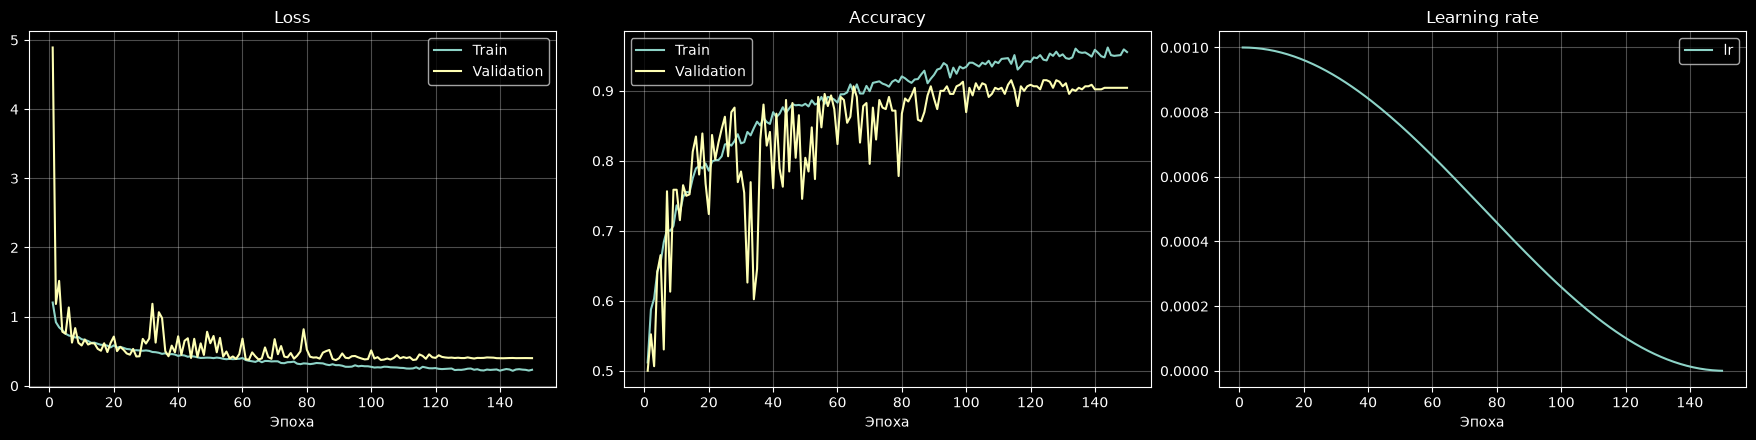

Эпоха 1/150 | loss=1.2041 acc=0.5120 | val_loss=4.8916 val_acc=0.5000 val_precision=0.5000 val_recall=0.5000
Эпоха 2/150 | loss=0.9195 acc=0.5875 | val_loss=1.1829 val_acc=0.5522 val_precision=0.5522 val_recall=0.5522
Эпоха 3/150 | loss=0.8456 acc=0.6033 | val_loss=1.5169 val_acc=0.5065 val_precision=0.5065 val_recall=0.5065
Эпоха 4/150 | loss=0.8033 acc=0.6418 | val_loss=0.7820 val_acc=0.6413 val_precision=0.6413 val_recall=0.6413
Эпоха 5/150 | loss=0.7532 acc=0.6543 | val_loss=0.7524 val_acc=0.6652 val_precision=0.6652 val_recall=0.6652
Эпоха 6/150 | loss=0.7273 acc=0.6837 | val_loss=1.1330 val_acc=0.5304 val_precision=0.5304 val_recall=0.5304
Эпоха 7/150 | loss=0.7171 acc=0.7016 | val_loss=0.6248 val_acc=0.7565 val_precision=0.7565 val_recall=0.7565
Эпоха 8/150 | loss=0.6978 acc=0.7000 | val_loss=0.8346 val_acc=0.6130 val_precision=0.6130 val_recall=0.6130
Эпоха 9/150 | loss=0.7046 acc=0.7071 | val_loss=0.6219 val_acc=0.7587 val_precision=0.7587 val_recall=0.7587
Эпоха 10/150 | loss

In [6]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=EPSILON,
    weight_decay=0 # L2 уже есть
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
#scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1)

criterion = torch.nn.CrossEntropyLoss()

best_val_loss = float("inf")
best_val_acc = float("-inf")
wait = 0

history = {
    name: []
    for name in (
        "loss", "acc", "precision", "recall",
        "val_loss", "val_acc", "val_precision", "val_recall", "lr",
    )
}

print(model)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")


def run_epoch(loader, training):
    model.train(training)

    total_loss = 0.0
    total_samples = 0
    correct = 0
    tp = fp = fn = 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if training:
                optimizer.zero_grad(set_to_none=True)

            #with torch.autocast(device_type="mps", dtype=torch.bfloat16):
            logits = model(images)
            loss = criterion(logits, labels) + model.l2_loss()

            if training:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_samples += batch_size
            total_loss += loss.detach().item() * batch_size

            with torch.no_grad():
                correct += (logits.argmax(dim=1) == labels).sum().item()

                # Precision/Recall:
                predicted = logits.softmax(dim=1) > 0.5
                actual = F.one_hot(
                    labels, num_classes=logits.size(1)
                ).bool()

                tp += (predicted & actual).sum().item()
                fp += (predicted & ~actual).sum().item()
                fn += (~predicted & actual).sum().item()

    return {
        "loss": total_loss / total_samples,
        "acc": correct / total_samples,
        "precision": tp / (tp + fp) if tp + fp else 0.0,
        "recall": tp / (tp + fn) if tp + fn else 0.0,
    }



def make_live_plot():
    # Виджет
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    lines = {}
    specs = [
        (ax[0], "Loss", [("loss", "Train"), ("val_loss", "Validation")]),
        (ax[1], "Accuracy", [("acc", "Train"), ("val_acc", "Validation")]),
        (ax[2], "Learning rate", [("lr", "lr")]),
    ]
    for axis, title, series in specs:
        axis.set_title(title)
        axis.set_xlabel("Эпоха")
        axis.grid(alpha=0.3)
        for key, label in series:
            (lines[key],) = axis.plot([], [], label=label)
        axis.legend()
    plt.tight_layout()
    plt.close(fig)
    handle = display(fig, display_id=True)
    return fig, ax, lines, handle


def update_live_plot(fig, ax, lines, handle, history):
    epochs = range(1, len(history["loss"]) + 1)
    for key, line in lines.items():
        line.set_data(epochs, history[key])
    for axis in ax:
        axis.relim()
        axis.autoscale_view()
    handle.update(fig)


live_fig, live_ax, live_lines, live_handle = make_live_plot()


for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(training_set, training=True)
    val_metrics = run_epoch(testing_set, training=False)

    for name, value in train_metrics.items():
        history[name].append(value)

    for name, value in val_metrics.items():
        history[f"val_{name}"].append(value)

    history["lr"].append(optimizer.param_groups[0]["lr"])
    scheduler.step()
    update_live_plot(live_fig, live_ax, live_lines, live_handle, history)

    print(
        f"Эпоха {epoch}/{EPOCHS} | "
        f"loss={train_metrics['loss']:.4f} "
        f"acc={train_metrics['acc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_acc={val_metrics['acc']:.4f} "
        f"val_precision={val_metrics['precision']:.4f} "
        f"val_recall={val_metrics['recall']:.4f}"
    )

    # Чекпойнт
    if SAVE_CHECKPOINT and val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": best_val_acc,
            "class_to_idx": train_dataset.class_to_idx,
            "target_size": TARGET_SIZE,
        }, "./base.pt")

        print("Сохранён чекпойнт: ./base.pt")

    # Earlystop
    if val_metrics["loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_metrics["loss"]
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Earlystop на эпохе {epoch}")
            break

## Итоговые метрики

In [7]:
model.eval()

all_labels = []
all_predictions = []
total_loss = torch.zeros((), device=device)
total_samples = 0

with torch.no_grad():
    for images, labels in testing_set:
        images = images.to(device)
        labels = labels.to(device)

        with torch.autocast(device_type="mps", dtype=torch.bfloat16):
            logits = model(images)
            loss = criterion(logits, labels)

        total_loss += loss * labels.size(0)
        total_samples += labels.size(0)

        all_labels.append(labels)
        all_predictions.append(logits.argmax(dim=1))

    test_loss = (total_loss / total_samples + model.l2_loss()).item()

y_true = torch.cat(all_labels).cpu().numpy()
y_pred = torch.cat(all_predictions).cpu().numpy()

class_names = test_dataset.classes
class_ids = np.arange(len(class_names))

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=class_ids,
    average="macro",
    zero_division=0,
)

print(f'\nTest Loss: {test_loss:.4f}')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}\n')

print(classification_report(
    y_true,
    y_pred,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0,
))


Test Loss: 0.4009
Accuracy:  0.9065
Precision: 0.9069
Recall:    0.9065
F1:        0.9065

              precision    recall  f1-score   support

   00-damage     0.8945    0.9217    0.9079       230
    01-whole     0.9193    0.8913    0.9051       230

    accuracy                         0.9065       460
   macro avg     0.9069    0.9065    0.9065       460
weighted avg     0.9069    0.9065    0.9065       460



## Результат
> Для простейшей CNN довольно не плохо, учитывая что датасет маленький всего - 1840 картинок 2 категорий, модель сумела поймать паттерны и обобщить классификацию\
> \
> К примеру предобученные модели семейства MobileNet(v1,v2,v3)+imagenet на 1,28 миллиона изображений и дообученые Fine-Tuning на данном датасете выдают точность(accuracy) порядка 94-97% 